# High-Performance Learning Dynamics in General-Sum Games
This notebook demonstrates how to run learning dynamics (OMWU, ExtraGradient, MWU, GDA) with high-performance PyTorch GPU acceleration, multi-step unrolling (`steps_per_call`), incremental chunked statistics loading (`load_experiment_stats`), and parallel multi-game ensemble evaluation (`BatchNPlayerGame`).

## 1. Single Experiment with Multi-Step Unrolling (`steps_per_call=500`)
Unrolling $K=500$ steps in PyTorch GPU execution blocks eliminates Python loop overhead and achieves maximum step throughput.

In [1]:
import sys; sys.path.append('..')
import torch
import matplotlib.pyplot as plt
from src.config.schemas import ExperimentConfig, GameConfig, DynamicConfig, ExecutionConfig
from src.engine.runner import ExperimentRunner
from src.engine.statistics import load_experiment_stats

# 1. Configure OMWU on Matching Pennies starting OFF-equilibrium ([0.8, 0.2] & [0.3, 0.7])
config = ExperimentConfig(
    name="demo",
    game=GameConfig(generator="custom", utility_range=(-1.0, 1.0), payoffs=[[[-0.1408, 0.1628], [-0.139, -0.1397]], [[ 0.0726, -0.574 ], [-0.5175, -0.1687]]]),
    dynamic=DynamicConfig(
        algorithm="omwu",
        strict_theory_eta=False,
        eta=0.05
    ),
    execution=ExecutionConfig(total_steps=400000, device="auto", steps_per_call=500, seed=42, compile=False)
)

# 2. Run simulation
runner = ExperimentRunner(config=config)
summary = runner.run()

[08/03/26 11:47:23] INFO     Starting simulation 'demo' [Session: 2699cd17-9ef7-4f6b-a863-fe5e0954b401] on device  
                             'cuda' for T=400000 steps.

Output()

[08/03/26 11:48:42] INFO     Simulation completed cleanly! Final Max Avg Regret: 0.000457. Stats session ID        
                             '2699cd17-9ef7-4f6b-a863-fe5e0954b401' in 'outputs'

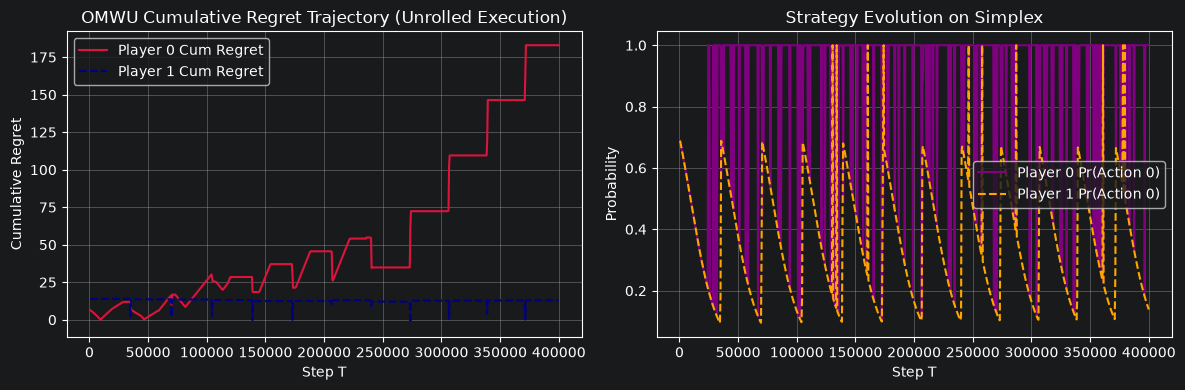

In [2]:
from src.engine.statistics import unpack_stats
from src.utils.visualization import plot_static_trajectories

# Load and unpack the recorded statistics from disk
stats_data = load_experiment_stats(output_dir=output_dir, session_id=session_id)
steps, cum_regrets, strats, logits, instant_payoffs = unpack_stats(stats_data)

# Plot the static N-player trajectories (Zoom in by setting start_step and end_step if desired!)
import torch
cum_action_payoffs = [torch.cumsum(p, dim=0) for p in instant_payoffs]
cum_expected_payoffs = [torch.cumsum(torch.sum(s * p, dim=-1), dim=0) for s, p in zip(strats, instant_payoffs)]
fig, axes = plot_static_trajectories(steps, cum_regrets, strats, title_prefix="OMWU", plot_all_actions=False, start_step=0, end_step=None, cum_action_payoffs=cum_action_payoffs, cum_expected_payoffs=cum_expected_payoffs)
plt.show()


In [3]:
strats[1][:, 0].numpy()


array([0.68909043, 0.67944723, 0.66956127, 0.65952325, 0.6493399 ,
       0.6390187 , 0.6285675 , 0.61799794, 0.6073228 , 0.5965441 ,
       0.5856714 , 0.57471454, 0.5636838 , 0.55258703, 0.5414367 ,
       0.5302445 , 0.5190219 , 0.5077803 , 0.49653104, 0.4852852 ,
       0.4740539 , 0.46284878, 0.45168108, 0.4405618 , 0.42950186,
       0.4185119 , 0.40760213, 0.39678282, 0.38606346, 0.3754548 ,
       0.36496994, 0.35461167, 0.34438795, 0.33430624, 0.32437366,
       0.31459674, 0.30498147, 0.2955334 , 0.28625745, 0.27715808,
       0.268237  , 0.25949645, 0.25094306, 0.24257925, 0.23440696,
       0.2264277 , 0.21864247, 0.2110519 , 0.20365615, 0.19645505,
       0.18944798, 0.18263406, 0.17601196, 0.16958018, 0.16333683,
       0.1572798 , 0.15140675, 0.14571507, 0.14020203, 0.13486461,
       0.12969975, 0.12470419, 0.11987557, 0.11520395, 0.11068981,
       0.10633131, 0.10212471, 0.09806686, 0.09434758, 0.1830372 ,
       0.6884304 , 0.6806792 , 0.6708143 , 0.6607949 , 0.65062

In [4]:
runner.game.get_payoff_tensors()

[tensor([[-0.1408,  0.1628],
         [-0.1390, -0.1397]], device='cuda:0'),
 tensor([[ 0.0726, -0.5740],
         [-0.5175, -0.1687]], device='cuda:0')]

## 2. Multi-Algorithm Benchmark (OMWU vs ExtraGradient vs MWU vs GDA)
Compare throughput and regret convergence across all 4 learning dynamics algorithms.

In [5]:
import time

algorithms = ["omwu", "mwu", "mirror_prox"]
results = {}

for algo in algorithms:
    exp = ExperimentConfig(
        name=f"benchmark_{algo}",
        game=GameConfig(generator="matching_pennies"),
        dynamic=DynamicConfig(algorithm=algo, strict_theory_eta=False),
        execution=ExecutionConfig(total_steps=20000, device="auto", steps_per_call=500, seed=42)
    )
    t0 = time.time()
    run_summary = ExperimentRunner(config=exp).run()
    elapsed = time.time() - t0
    sps = 20000 / elapsed
    results[algo] = sps
    print(f"Algorithm {algo.upper():16s}: {sps:6.1f} steps/second")

[08/03/26 11:48:43] INFO     Inferred OMWU empirical eta = 0.062500 (1 / (8 * max(A)))

[08/03/26 11:48:43] INFO     Starting simulation 'benchmark_omwu' [Session: 7b88c6e8-8a36-4244-8f4a-7421b74416f1]  
                             on device 'cuda' for T=20000 steps.

Output()

[08/03/26 11:48:47] INFO     Simulation completed cleanly! Final Max Avg Regret: 0.000000. Stats session ID        
                             '7b88c6e8-8a36-4244-8f4a-7421b74416f1' in 'outputs'

Algorithm OMWU            : 5207.9 steps/second


...

[08/03/26 11:48:50] INFO     Inferred MirrorProx empirical eta = 0.015625 (1 / (16 * N * max(A)))

                    INFO     Starting simulation 'benchmark_mirror_prox' [Session:                                 
                             f779c081-ea8c-4dff-af21-b4339ad6f848] on device 'cuda' for T=20000 steps.

Output()

[08/03/26 11:48:56] INFO     Simulation completed cleanly! Final Max Avg Regret: 0.000000. Stats session ID        
                             'f779c081-ea8c-4dff-af21-b4339ad6f848' in 'outputs'

Algorithm MIRROR_PROX     : 3457.9 steps/second


## 3. Parallel Multi-Game Ensemble Execution (`BatchNPlayerGame`)
Simulate $B=100$ random game instances in parallel on GPU simultaneously using batched tensor contractions.

In [6]:
from src.games.nplayer_game import BatchNPlayerGame
from src.dynamics.omwu import OptimisticMWU

B = 100  # 100 parallel game instances
N = 3    # 3-player games
actions = [3, 3, 3]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Generate 100 random game payoff matrices on GPU
batch_payoffs = [
    torch.randn(B, *actions, device=device, dtype=torch.float32)
    for _ in range(N)
]
batch_game = BatchNPlayerGame(batch_payoffs=batch_payoffs, device=device)

# Initialize OMWU dynamics for all 100 games simultaneously
dynamic = OptimisticMWU(action_sizes=actions, T=10000, strict_theory_eta=False, device=device)
dynamic.reset()

print(f"Successfully initialized ensemble of {B} parallel 3-player games on device '{device}'!")

[08/03/26 11:48:56] INFO     Inferred OMWU empirical eta = 0.041667 (1 / (8 * max(A)))

Successfully initialized ensemble of 100 parallel 3-player games on device 'cuda'!
